68.45089147491359


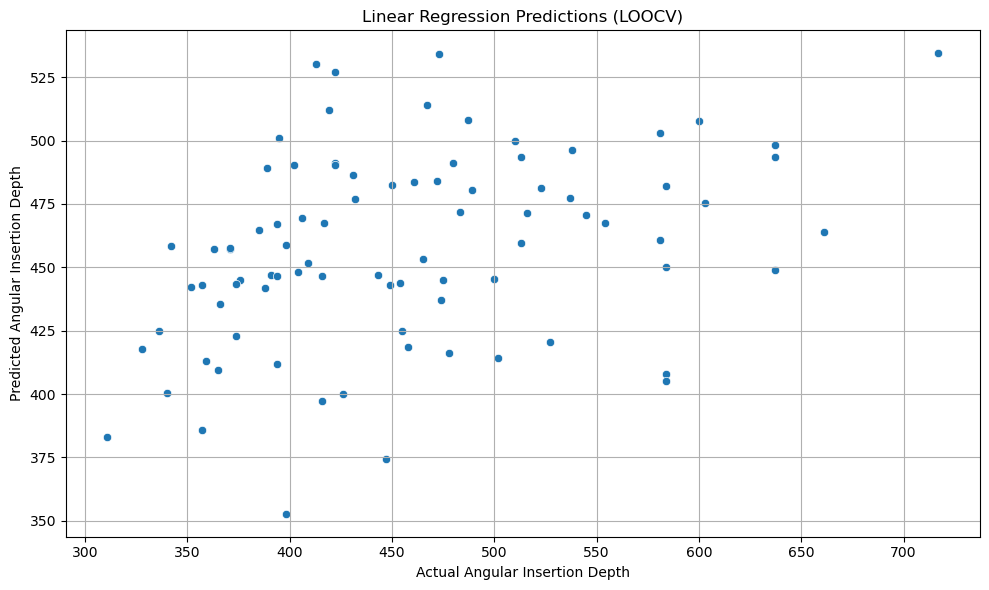

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error
import numpy as np

# Data extracted from the PDF Table 6 (86 rows)
data = pd.read_csv("Capstone Dataset.csv")

#CLean up nan values
data2 = data.dropna().copy()

# Convert to DataFrame
df = pd.DataFrame(data2, columns=["BID (mm)", "Cochlear scale (mm)", "Actual angular insertion depth (deg)", "Array Length (mm)", "Array Diameter (mm)"])

# Define features and target
X = df[["BID (mm)", "Cochlear scale (mm)"]]
y = df["Actual angular insertion depth (deg)"]

# Perform Leave-One-Out Cross-Validation
loo = LeaveOneOut()
mae_scores = []
y_preds = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)[0]
    y_preds.append(y_pred)
    mae_scores.append(mean_absolute_error([y_test], [y_pred]))

# Compute average MAE
average_mae = np.mean(mae_scores)

import matplotlib.pyplot as plt
import seaborn as sns

# Plot predictions vs actuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=y_preds)
plt.xlabel("Actual Angular Insertion Depth")
plt.ylabel("Predicted Angular Insertion Depth")
plt.title("Linear Regression Predictions (LOOCV)")
plt.grid(True)
plt.tight_layout()

print(average_mae)
#import ace_tools as tools; tools.display_dataframe_to_user(name="LOOCV Prediction Results", dataframe=df.assign(Predicted_Angular_Depth=y_preds))


31.619729242184977


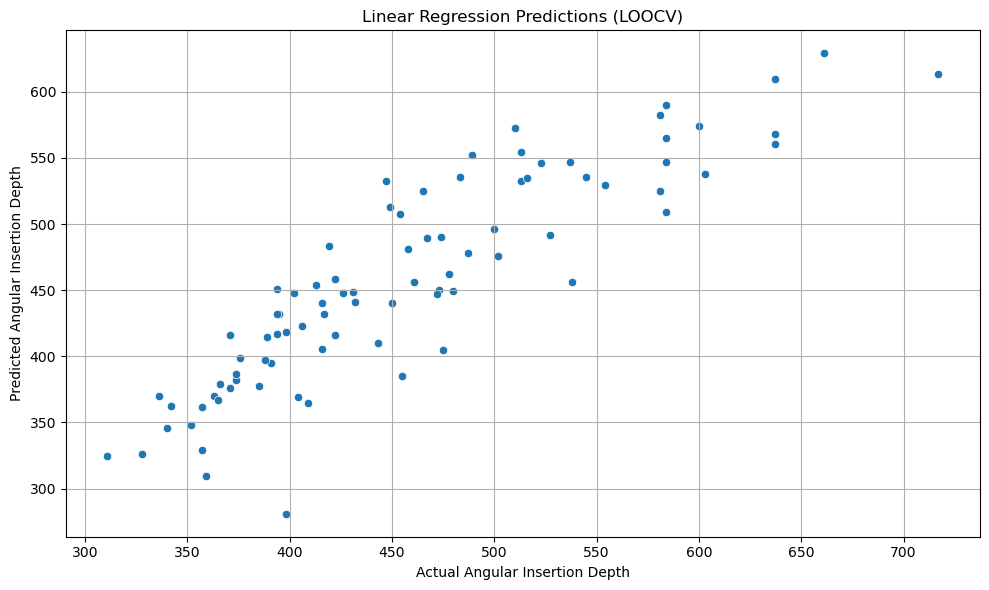

In [3]:
data = pd.read_csv("Capstone Dataset (New).csv")

#CLean up nan values
data2 = data.dropna().copy()

# Convert to DataFrame
df = pd.DataFrame(data2, columns=["BID (mm)", "Cochlear scale (mm)", "Actual angular insertion depth (deg)", "Array Length (mm)", "Array Diameter (mm)"])

# Define features and target
X = df[["BID (mm)", "Cochlear scale (mm)", "Array Length (mm)", "Array Diameter (mm)"]]
y = df["Actual angular insertion depth (deg)"]

# Perform Leave-One-Out Cross-Validation
loo = LeaveOneOut()
mae_scores = []
y_preds = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)[0]
    y_preds.append(y_pred)
    mae_scores.append(mean_absolute_error([y_test], [y_pred]))

# Compute average MAE
average_mae2 = np.mean(mae_scores)

import matplotlib.pyplot as plt
import seaborn as sns

# Plot predictions vs actuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=y_preds)
plt.xlabel("Actual Angular Insertion Depth")
plt.ylabel("Predicted Angular Insertion Depth")
plt.title("Linear Regression Predictions (LOOCV)")
plt.grid(True)
plt.tight_layout()

print(average_mae2)


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import numpy as np

# Loaded dataset 
df = pd.read_csv("Capstone Dataset (New).csv")

# Separated features (X) and target (y)
X = df.drop(["Array type", "Predicted angular insertion depth (deg)", 
            "Actual angular insertion depth (deg)"], axis=1)  
y = df["Actual angular insertion depth (deg)"]

# LOO
loo = LeaveOneOut()
mae_scores = []
y_preds = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    
    xgb_reg = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    # Fit model
    xgb_reg.fit(X_train, y_train)
    
    # Predictions
    y_pred = xgb_reg.predict(X_test)
    y_preds.append(y_pred)
    mae_scores.append(mean_absolute_error([y_test], [y_pred]))

# Evaluation
average_mae2 = np.mean(mae_scores)

print("MAE:", average_mae2)

MAE: 39.7542540084484


In [10]:
#Attempting to get better result with GridSearch CV

import xgboost as xgb
from sklearn.model_selection import GridSearchCV

#Creating a GridSearch 

# Setting up the grid search
param_grid = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

grid_search = GridSearchCV(estimator=xgb_reg,
                           param_grid=param_grid,
                           scoring='neg_mean_absolute_error',
                           cv=5,
                           n_jobs=-1,
                           verbose=2)

# Running the grid search on my training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=0.8,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    max_depth=6, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=500,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8, 0.9],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [4, 6, 8],
                         'n_estimators': [300, 500, 700],
                         'subsample': [0.7, 0.8, 0.9]},
             scoring='neg_mean_absolute_error', verbose=2)

In [11]:
#The best combination of parameters
print(f"The Best Parameters are: {grid_search.best_params_}")

# The best MAE score
best_mae = -grid_search.best_score_
print(f"The Best Cross-Validated MAE is: {best_mae:.4f}")

#To get the best model and use it for final predictions
best_xgb_model = grid_search.best_estimator_

The Best Parameters are: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
The Best Cross-Validated MAE is: 46.6862


In [2]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

#Loading dataset
df = pd.read_csv("Capstone Dataset (New).csv")

#Separate=ing features (X) and target (y)
X = df.drop(
    ["Array type", "Predicted angular insertion depth (deg)",
     "Actual angular insertion depth (deg)"],
    axis=1
)
y = df["Actual angular insertion depth (deg)"]

#Leave-One-Out Method
loo = LeaveOneOut()

y_true_all = []
y_pred_all = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

#AdaBoost regressor
    ada = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    )

#Fit model
    ada.fit(X_train, y_train)

#Predict the held-out sample
    y_pred = ada.predict(X_test)[0]

    # Collect predictions and truth
    y_pred_all.append(y_pred)
    y_true_all.append(y_test.values[0])

# Evaluation (overall MAE across all LOO folds)
mae = mean_absolute_error(y_true_all, y_pred_all)
print("MAE:", mae)

MAE: 38.22397122672426
